In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import os
import cv2
import re

In [2]:
path = os.listdir('/kaggle/input/datasets/dasmehdixtr/drone-dataset-uav/dataset_xml_format/dataset_xml_format')

In [3]:
base_path = '/kaggle/input/datasets/dasmehdixtr/drone-dataset-uav/dataset_xml_format/dataset_xml_format'
images = [i for i in os.listdir(base_path) if i.endswith('.png')]

In [4]:
X = []
y = []
for i in images:
    try:
        image_path = os.path.join(base_path, i)
        image = cv2.imread(image_path)
        shape_x = image.shape[1]
        shape_y = image.shape[0]
        image = cv2.resize(image, (224,224))
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        X.append(image)
        xml_path = image_path.replace('.png', '.xml')
        with open(xml_path, 'r', encoding='utf-8') as file:
            text = file.read()
        xmin,ymin,xmax,ymax = map(int, re.findall(r'(?:<xmin>|<ymin>|<xmax>|<ymax>)(\d*)(?:</xmin>|</ymin>|</xmax>|</ymax>)', text)[:4])
        xmin = xmin * 224 / shape_x
        ymin = ymin * 224 / shape_y
        xmax = xmax * 224 / shape_x
        ymax = ymax * 224 / shape_y
        y.append([xmin,ymin,xmax,ymax])
        flipped_image = cv2.flip(image, 1)
        f_xmin = 224 - xmax
        f_xmax = 224 - xmin
        X.append(flipped_image)
        y.append([f_xmin,ymin,f_xmax,ymax])
    except:
        print('no')
X = np.array(X)
y = np.array(y)

In [5]:
X.shape, y.shape

((600, 224, 224, 3), (600, 4))

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
y_train = y_train / 224.0
y_test = y_test / 224.0

In [9]:
y_train[0]

array([0.38046875, 0.46944444, 0.46953125, 0.55555556])

In [10]:
from keras import Sequential, layers
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.applications import EfficientNetB0
from keras.optimizers import Adam

2026-04-15 06:34:14.290053: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776234854.685237      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776234854.791641      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776234855.676103      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776234855.676156      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776234855.676161      55 computation_placer.cc:177] computation placer alr

In [11]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

2026-04-15 06:34:43.581321: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [34]:
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [35]:
model = Sequential([

base_model,
GlobalAveragePooling2D(),

Dense(512, activation='relu'),
Dropout(0.4),
Dense(256, activation='relu'),
Dropout(0.2),
Dense(4, activation='sigmoid')
])

In [36]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mae')

In [37]:
model.fit(X_train,y_train, validation_split=0.15, epochs=30, batch_size=32)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - loss: 0.1694 - val_loss: 0.1055
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - loss: 0.1187 - val_loss: 0.0902
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - loss: 0.0984 - val_loss: 0.0840
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - loss: 0.0975 - val_loss: 0.0782
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - loss: 0.0912 - val_loss: 0.0792
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - loss: 0.0889 - val_loss: 0.0765
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - loss: 0.0864 - val_loss: 0.0730
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - loss: 0.0796 - val_loss: 0.0699
Epoch 9/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - loss: 0.0757 - val_loss: 0.0695
Epoch 10/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - loss: 0.0694 - val_loss: 0.0719
Epoch 11/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - loss: 0.0707 - val_loss: 0.0662
Epoch 12/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - loss: 0.0708 - val_lo

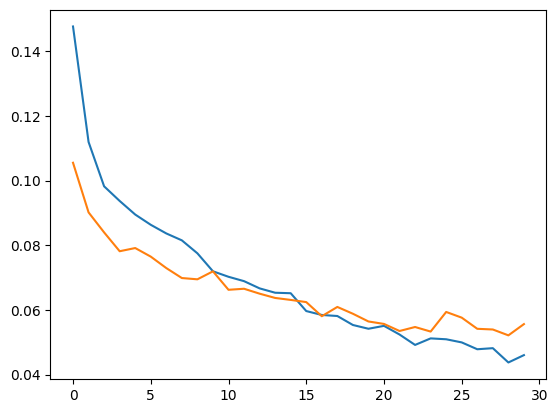

In [39]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [40]:
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.0693


0.06477794051170349

#### TEST

In [41]:
new_ = img.imread('/kaggle/input/datasets/samvelgalstyan/ggggggggg/drone3.jfif')

In [42]:
new_image = new_.copy()

In [43]:
new_.shape, new_image.shape

((168, 300, 3), (168, 300, 3))

In [44]:
# new_image = new_image[:, :, :3]
new_image = cv2.resize(new_image, (224,224))
new_image = new_image.reshape(1,224,224,3)

In [45]:
xmin,ymin,xmax,ymax = map(int, model.predict(new_image)[0] * 224)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [46]:
xmin,ymin,xmax,ymax

(49, 25, 173, 152)

In [47]:
new_image = new_image.reshape(224,224,3).astype('uint8')

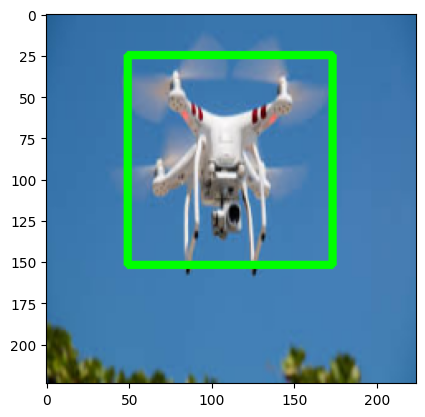

In [48]:
plt.imshow(cv2.rectangle(new_image, (xmin,ymin),(xmax,ymax), (0,255,0), 3))